# Post-hoc analysis from a saved inversion bundle

An inversion saved with `run_halo.py --save DIR` (or `save_inversion(...)`) can be reloaded and analyzed **without re-reading the Jacobian or re-solving** — aggregation and disaggregation are linear functionals of the posterior, and the bundle stores the factors that reproduce `aᵀx̂` and `aᵀŜa` exactly.

This notebook demonstrates the reader (`load_inversion` → `SavedInversion`) and useful plots:

1. Load + inspect the bundle
2. Posterior scalar fields and their uncertainty
3. Observation diagnostics (obs / background / enhancement / modeled / residual / outliers)
4. The retrieved background offset(s)
5. **Post-hoc re-aggregation with uncertainty**: domain total, regional sub-totals, and sector totals with their cross-covariance

Point `BUNDLE_DIR` at one of your real bundles to use real results; otherwise a small synthetic bundle is built so the notebook runs anywhere.

In [1]:
import os, sys, tempfile
import numpy as np
import matplotlib.pyplot as plt

BAYES_OPT = os.path.dirname(os.path.dirname(os.path.abspath('saved_bundle_analysis.ipynb')))
if BAYES_OPT not in sys.path:
    sys.path.insert(0, BAYES_OPT)
import halo_oe  # noqa: F401

from halo_oe.io_bundle import load_inversion
from halo_oe.flux import cell_areas_m2

# Set this to a real bundle directory (from `run_halo.py --save`) to analyze real
# results. If it does not exist, a small synthetic bundle is built below.
BUNDLE_DIR = os.environ.get('HALO_BUNDLE', '/tmp/halo_demo_bundle')

## Setup: build a small synthetic bundle if none is provided

(Skipped automatically if `BUNDLE_DIR` already exists. With a real bundle the plots below are meaningful; the synthetic one just exercises the reader.)

In [2]:
def _build_demo_bundle(dirpath):
    import netCDF4, h5py
    from goe.config import Config
    from adapters.gridded_state import Grid
    from halo_oe.emissions import category_priors_on_grid
    from halo_oe.pipeline import load_context, invert
    from halo_oe.io_bundle import save_inversion
    rng = np.random.default_rng(0)
    lat = np.linspace(40.4, 41.1, 20); lon = np.linspace(-74.3, -73.5, 20)
    glat, glon = np.meshgrid(lat, lon, indexing='ij')
    tmp = tempfile.mkdtemp()

    # synthetic inventory: labelled sub-categories -> distinct super-categories,
    # each a spatially distinct source
    elat = np.linspace(40.0, 41.5, 16); elon = np.linspace(-74.8, -73.0, 16)
    eglat, eglon = np.meshgrid(elat, elon, indexing='ij')
    def egauss(lat0, lon0, w): return np.exp(-(((eglat-lat0)/w)**2 + ((eglon-lon0)/w)**2))
    labels = ['Fuel exploitation GAS', 'Solid waste landfills', 'Waste water handling',
              'Combustion for manufacturing']
    centers = [(40.7,-74.0,0.15), (40.8,-73.8,0.08), (40.6,-73.9,0.07), (40.9,-74.1,0.2)]
    edgar = np.stack([1 + 6*egauss(*c) for c in centers])
    emis_path = os.path.join(tmp, 'emis.h5')
    with h5py.File(emis_path, 'w') as f:
        f.create_dataset('lat', data=elat); f.create_dataset('lon', data=elon)
        f.create_dataset('edgar', data=edgar); f.attrs['edgar_categories'] = ';'.join(labels)
        for s in ('epa', 'pitt'):
            f.create_dataset(s, data=edgar.copy()); f.attrs[f'{s}_categories'] = ';'.join(labels)

    # synthetic Jacobian (non-negative), and OBSERVATIONS from a known truth so the
    # demo inversion is well-posed and the recovered scalars stay near 1:
    #   obs = baseline + H @ (prior_total * true_scalar),  with H scaled so that the
    #   enhancement at scalar = 1 is ~0.25 ppm (the scale lives in H, not the scalars)
    nrec = 60
    prior_tot = category_priors_on_grid(emis_path, Grid(lat, lon), sources=('edgar',))['edgar']
    true_scalar = 1.0 + 0.6*np.exp(-(((glat-40.8)/0.15)**2 + ((glon+74.0)/0.15)**2))  # +60% bump
    H01 = rng.uniform(0, 1, (nrec, len(lat), len(lon)))
    base_enh = H01.reshape(nrec, -1) @ prior_tot.reshape(-1)    # enhancement at scalar = 1
    H = H01 * (0.25 / base_enh.mean())                          # scale Jacobian -> ~0.25 ppm
    enh = H.reshape(nrec, -1) @ (prior_tot * true_scalar).reshape(-1)
    obs = 1.9 + enh + 0.01*rng.standard_normal(nrec)
    with netCDF4.Dataset(os.path.join(tmp, 'demo.nc'), 'w') as ds:
        ds.createDimension('receptor', nrec)
        ds.createDimension('emitter_lat', len(lat)); ds.createDimension('emitter_lon', len(lon))
        ds.createVariable('emissions_lat', 'f8', ('emitter_lat',))[:] = lat
        ds.createVariable('emissions_lon', 'f8', ('emitter_lon',))[:] = lon
        ds.createVariable('jacobian', 'f8', ('receptor', 'emitter_lat', 'emitter_lon'))[:] = H
        ds.createVariable('receptor_xch4', 'f8', ('receptor',))[:] = obs
        ds.createVariable('receptor_lat', 'f8', ('receptor',))[:] = rng.uniform(lat[0], lat[-1], nrec)
        ds.createVariable('receptor_lon', 'f8', ('receptor',))[:] = rng.uniform(lon[0], lon[-1], nrec)

    cfg = Config(mapping={
        'jacobian': {'dir': tmp, 'flights': 'demo', 'in_memory': 'true'},
        'domain': {'bbox': '[40.5, 41.0, -74.2, -73.6]'},
        'emissions': {'path': emis_path, 'inventory': 'edgar', 'compare': 'edgar'},
        'background': {'method': 'planar', 'degree': '1', 'domain_sensitivity_quantile': '1.0'},
        'prior': {'scalar_stddev': '0.5', 'correlation_length_km': '3'},
        'observations': {'error_stddev': '0.01', 'baseline': '1.9'},
        'offset': {'n_groups': '1', 'stddev': '0.02'},
        'decomposition': {'enabled': 'true', 'method': 'category_fields'},
        'category_uncertainty': {'default': '0.5'},
        'category_spatial': {'default': '0', 'natural_gas': '5', 'combustion': '5'},
        'flux': {'unit_scale': '1.0'},
    })
    ctx = load_context(cfg, inventories=['edgar'])
    res = invert(ctx, 'edgar', decompose=True, method='category_fields')
    save_inversion(dirpath, ctx, res)

if not os.path.isdir(BUNDLE_DIR):
    print('building synthetic demo bundle at', BUNDLE_DIR)
    _build_demo_bundle(BUNDLE_DIR)
else:
    print('using existing bundle at', BUNDLE_DIR)

building synthetic demo bundle at /tmp/halo_demo_bundle


## 1. Load and inspect the bundle

`load_inversion` returns a `SavedInversion` with the reconstructed `posterior` (working `mean` / `cov_matvec` / `variances`), the `state`/`core`/`grid`, the super-category prior fields, the per-receptor table, and the saved report — **no Jacobian needed**.

In [3]:
inv = load_inversion(BUNDLE_DIR)
print('inventory :', inv.inventory, '| mode:', inv.mode, '| flights:', inv.flight_ids)
print('state     :', [(b.name, b.size) for b in inv.state.blocks], '-> dim', inv.state.size)
print('diagnostics:', {k: round(v, 3) for k, v in inv.diagnostics.items()})
print('\nsaved flux report:')
for nm, pr, po, sd in zip(inv.report['names'], inv.report['prior'],
                          inv.report['posterior'], inv.report['posterior_stddev']):
    print(f'  {nm:<12} prior {pr:.4g}  posterior {po:.4g} +/- {sd:.3g}')

inventory : edgar | mode: category_fields | flights: ['demo']
state     : [('natural_gas', 196), ('landfill', 196), ('wastewater', 196), ('combustion', 196), ('bc', 1)] -> dim 785
diagnostics: {'reduced_chi_square': 1.597, 'n_obs_used': 60.0, 'n_outliers': 0.0, 'degrees_of_freedom': 3.025}

saved flux report:
  natural_gas  prior 6.635e+09  posterior 6.391e+09 +/- 3.25e+08
  landfill     prior 4.083e+09  posterior 4.037e+09 +/- 1.8e+08
  wastewater   prior 3.516e+09  posterior 3.481e+09 +/- 1.43e+08
  combustion   prior 6.773e+09  posterior 6.558e+09 +/- 3.33e+08
  total        prior 2.101e+10  posterior 2.047e+10 +/- 5.12e+08


## 2. Posterior scalar fields and uncertainty

`inv.field(name)` scatters a block's posterior onto the grid; the uncertainty field comes from the posterior standard deviations. Cropped to the active domain.

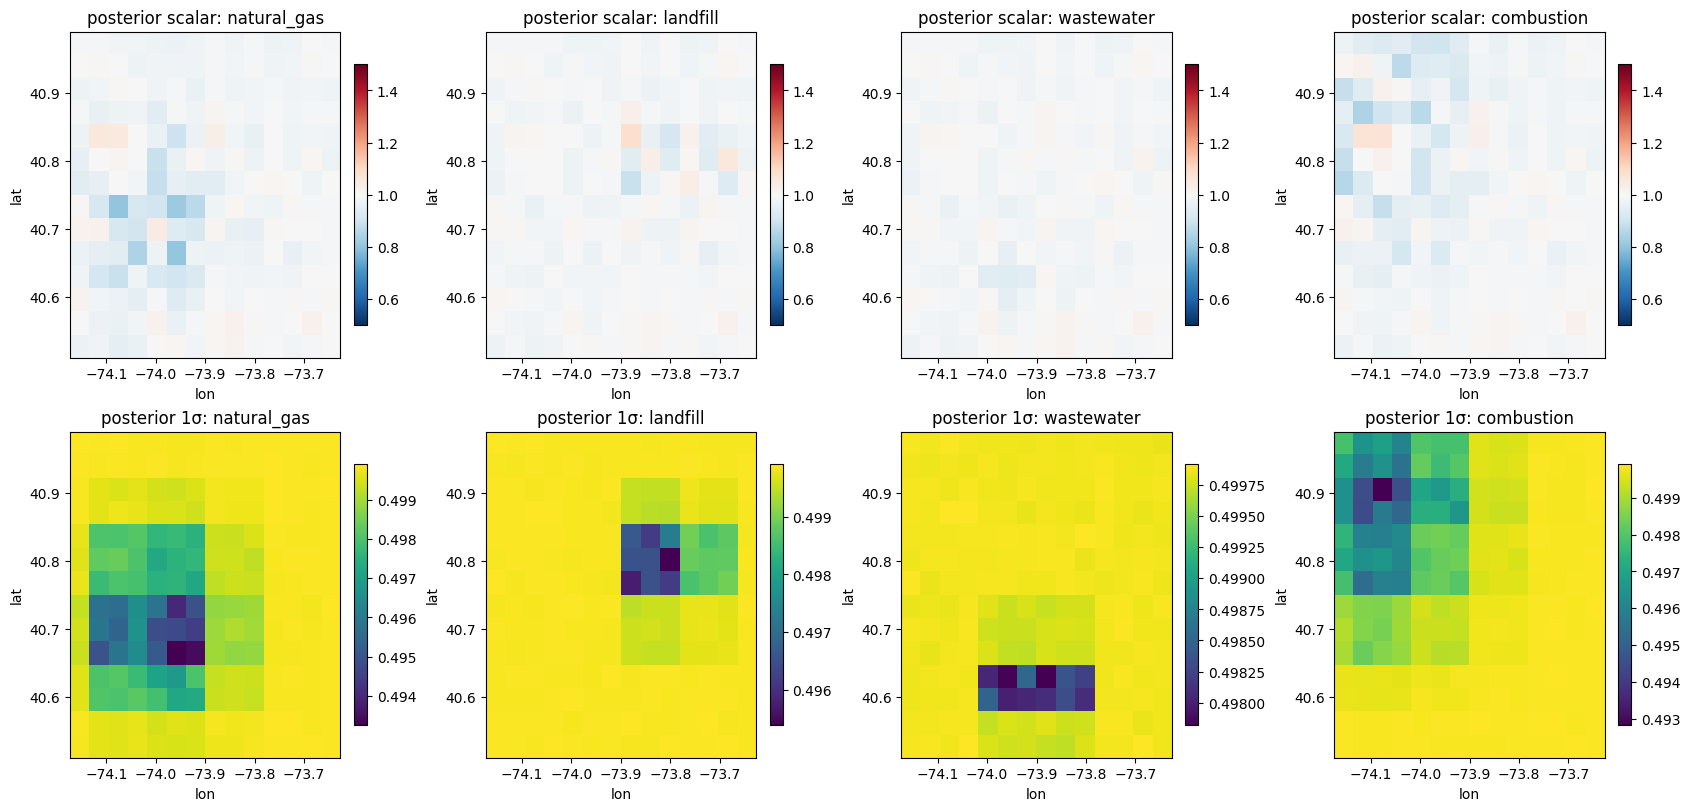

In [4]:
grid, core = inv.grid, inv.core
m = core.mask
rows = np.where(m.any(1))[0]; cols = np.where(m.any(0))[0]
r0, r1, c0, c1 = rows[0], rows[-1]+1, cols[0], cols[-1]+1
EXTENT = [grid.lon[c0], grid.lon[c1-1], grid.lat[r0], grid.lat[r1-1]]
crop = lambda f: f[r0:r1, c0:c1]

cats = [b.name for b in inv.state.blocks if b.name != 'bc']
std_parts = inv.state.unpack(inv.posterior.stddev())
fig, ax = plt.subplots(2, len(cats), figsize=(4.2*len(cats), 8), constrained_layout=True, squeeze=False)
for j, name in enumerate(cats):
    im0 = ax[0, j].imshow(crop(inv.field(name)), origin='lower', extent=EXTENT, aspect='auto',
                          cmap='RdBu_r', vmin=0.5, vmax=1.5)
    ax[0, j].set_title(f'posterior scalar: {name}'); fig.colorbar(im0, ax=ax[0, j], shrink=0.8)
    ustd = core.to_field(std_parts[name])
    im1 = ax[1, j].imshow(crop(ustd), origin='lower', extent=EXTENT, aspect='auto', cmap='viridis')
    ax[1, j].set_title(f'posterior 1\u03c3: {name}'); fig.colorbar(im1, ax=ax[1, j], shrink=0.8)
for a in ax.ravel(): a.set_xlabel('lon'); a.set_ylabel('lat')
plt.show()

## 3. Observation diagnostics

The bundle stores the per-receptor observation context: observed XCH4, fitted background, enhancement (`z = obs - bg`), modeled value (`Hx̂`, NaN for dropped outliers), flight index, and outlier flag. Residual = enhancement − modeled.

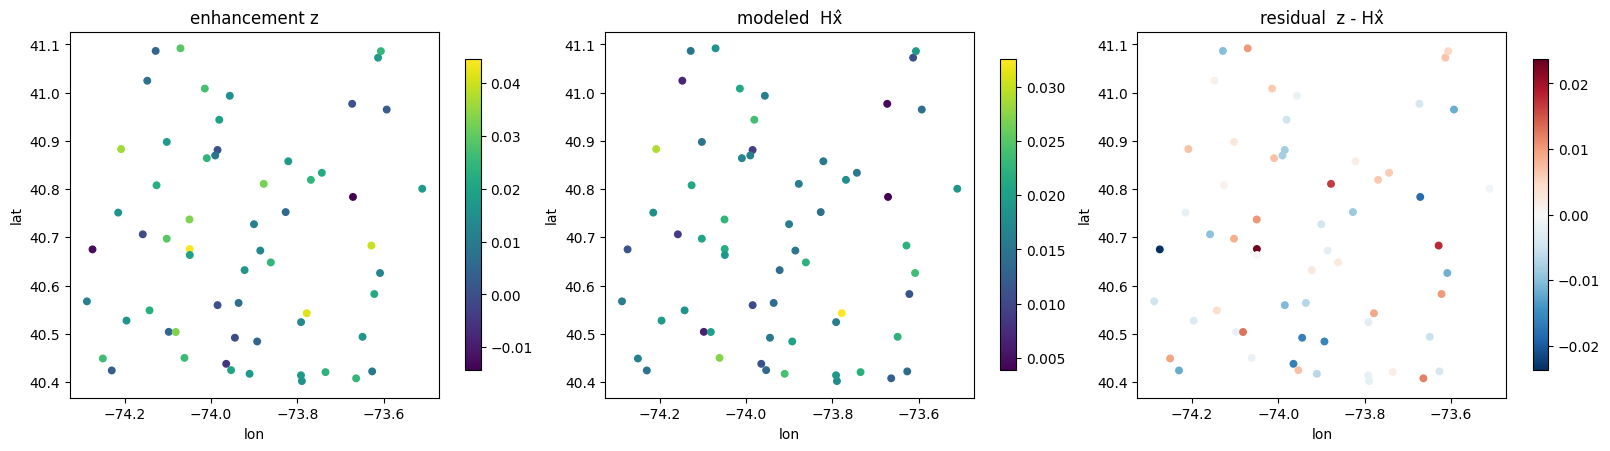

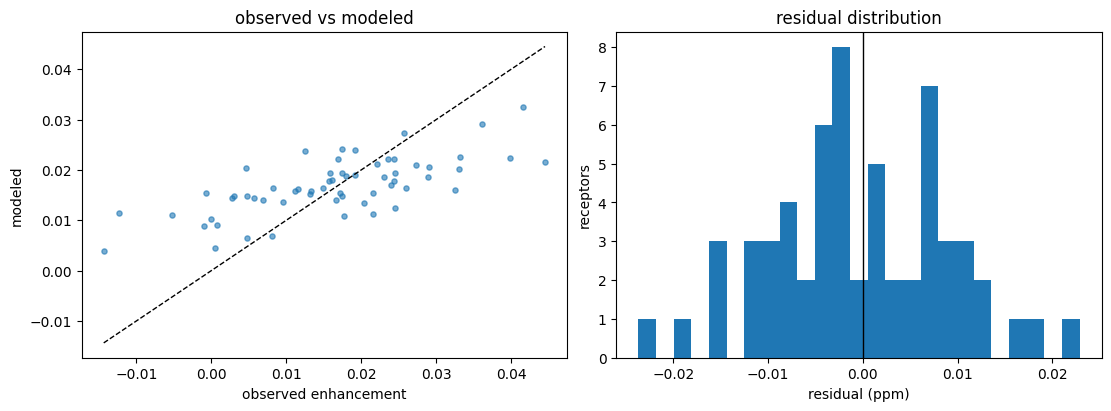

In [5]:
R = inv.receptors
rlat, rlon = R['receptor_lat'], R['receptor_lon']
z, modeled = R['enhancement'], R['modeled']
resid = z - modeled
flag = R.get('outlier_flag', np.zeros_like(rlat)).astype(bool)

fig, ax = plt.subplots(1, 3, figsize=(16, 4.4), constrained_layout=True)
for a, (title, val, cmap) in zip(ax, [('enhancement z', z, 'viridis'),
        ('modeled  Hx\u0302', modeled, 'viridis'), ('residual  z - Hx\u0302', resid, 'RdBu_r')]):
    vlim = np.nanmax(np.abs(resid)) if cmap == 'RdBu_r' else None
    kw = dict(vmin=-vlim, vmax=vlim) if vlim else {}
    s = a.scatter(rlon, rlat, c=val, s=22, cmap=cmap, **kw)
    if flag.any():
        a.scatter(rlon[flag], rlat[flag], s=80, facecolors='none', edgecolors='k', label='outlier')
        a.legend(loc='upper left')
    a.set_title(title); a.set_xlabel('lon'); a.set_ylabel('lat'); fig.colorbar(s, ax=a, shrink=0.85)
plt.show()

fig, ax = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
ax[0].scatter(z, modeled, s=14, alpha=0.6); lim = [np.nanmin(z), np.nanmax(z)]
ax[0].plot(lim, lim, 'k--', lw=1); ax[0].set_xlabel('observed enhancement'); ax[0].set_ylabel('modeled')
ax[0].set_title('observed vs modeled')
ax[1].hist(resid[np.isfinite(resid)], bins=25); ax[1].axvline(0, color='k', lw=1)
ax[1].set_xlabel('residual (ppm)'); ax[1].set_ylabel('receptors'); ax[1].set_title('residual distribution')
plt.show()

## 4. Retrieved background offset(s)

One optimized offset per flight, on top of the fitted background plane.

In [6]:
if 'bc' in inv.state.names:
    bc = inv.block('bc'); bc_sd = inv.state.unpack(inv.posterior.stddev())['bc']
    for fid, v, s in zip(inv.flight_ids, bc, bc_sd):
        print(f'  background offset [{fid}]: {v:+.4f} +/- {s:.4f} ppm')
else:
    print('no background-offset block in this inversion')

  background offset [demo]: -0.1276 +/- 0.0038 ppm


## 5. Post-hoc re-aggregation with uncertainty

This is the payoff: define **any** linear functional of the state and get its posterior mean and uncertainty via `inv.estimate(A)` — exact, no operator. The integrated flux of a region is `Σ_cells scalar × prior × area` over that region, which is linear in the state. Below: the domain total, a tiled regional breakdown, and the sector totals with their cross-covariance.

In [7]:
areas = core.from_field(cell_areas_m2(grid))                 # m^2 per active cell
gridded = [b.name for b in inv.state.blocks if b.name != 'bc']

def block_prior(name):
    """Prior emission on active cells for a state block (category field or total)."""
    if name in inv.group_fields:
        return inv.group_fields[name]
    return sum(inv.group_fields.values())                    # single-inventory 'total' block

def flux_functional(cell_weight=None, blocks=None):
    """Aggregation vector a so that aᵀx = integrated flux over the (weighted) region."""
    a = np.zeros(inv.state.size)
    for name in (blocks or gridded):
        w = block_prior(name) * areas
        if cell_weight is not None:
            w = w * cell_weight
        a[inv.state.slice(name)] = w
    return a

# domain total +/- 1 sigma
(tot,), totcov = inv.estimate(flux_functional()[None, :])
print(f'domain total flux: {tot:.4e} +/- {totcov[0,0]**0.5:.3e}  ({inv.report["unit_label"]})')

domain total flux: 2.0467e+10 +/- 5.123e+08  (prior-units x m^2 (native))


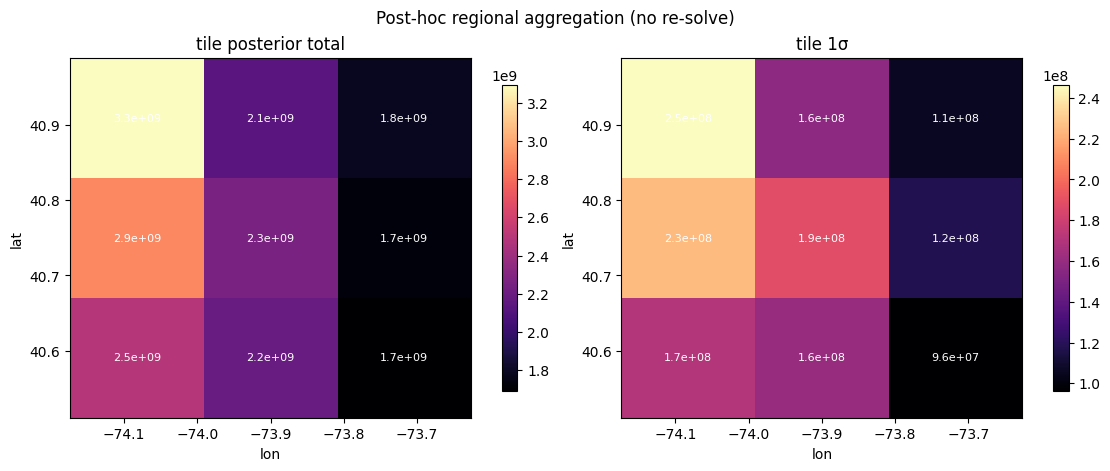

tiles sum to 2.0467e+10 vs domain total 2.0467e+10


In [8]:
# regional sub-totals: split the active domain into an NxN grid of tiles and
# aggregate each (with uncertainty) post-hoc
N = 3
alat, alon = core.active_lat, core.active_lon
lat_edges = np.linspace(alat.min(), alat.max()+1e-9, N+1)
lon_edges = np.linspace(alon.min(), alon.max()+1e-9, N+1)
rowsA = []
for i in range(N):
    for j in range(N):
        w = ((alat >= lat_edges[i]) & (alat < lat_edges[i+1]) &
             (alon >= lon_edges[j]) & (alon < lon_edges[j+1])).astype(float)
        rowsA.append(flux_functional(cell_weight=w))
means, cov = inv.estimate(np.array(rowsA))
tile_tot = means.reshape(N, N); tile_sd = np.sqrt(np.clip(np.diag(cov), 0, None)).reshape(N, N)

fig, ax = plt.subplots(1, 2, figsize=(11, 4.6), constrained_layout=True)
ext = [lon_edges[0], lon_edges[-1], lat_edges[0], lat_edges[-1]]
for a, (title, fld) in zip(ax, [('tile posterior total', tile_tot), ('tile 1\u03c3', tile_sd)]):
    im = a.imshow(fld, origin='lower', extent=ext, aspect='auto', cmap='magma')
    for i in range(N):
        for j in range(N):
            a.text((lon_edges[j]+lon_edges[j+1])/2, (lat_edges[i]+lat_edges[i+1])/2,
                   f'{fld[i,j]:.1e}', ha='center', va='center', color='w', fontsize=8)
    a.set_title(title); a.set_xlabel('lon'); a.set_ylabel('lat'); fig.colorbar(im, ax=a, shrink=0.85)
plt.suptitle('Post-hoc regional aggregation (no re-solve)'); plt.show()
print(f'tiles sum to {tile_tot.sum():.4e} vs domain total {tot:.4e}')

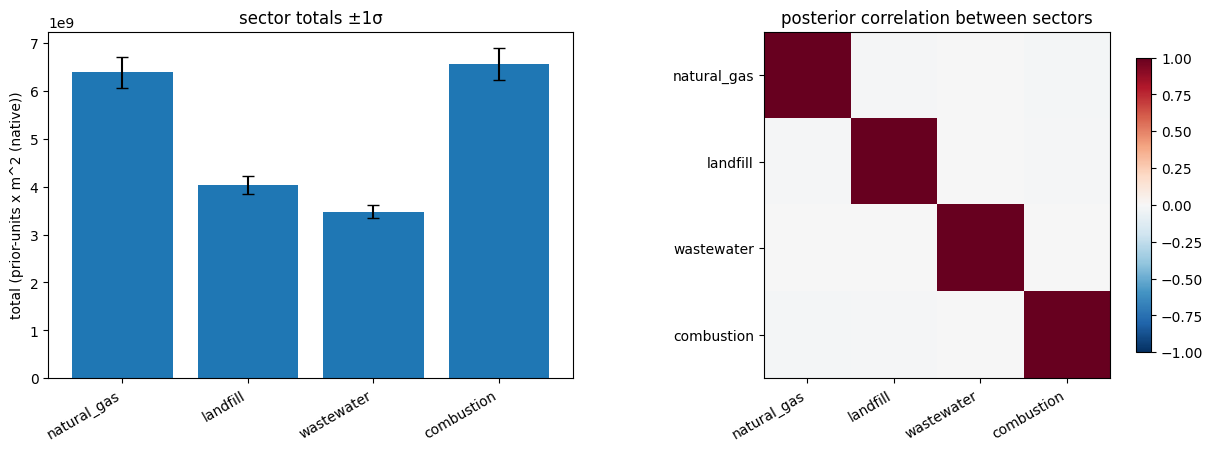

sector totals sum to 2.0467e+10 vs domain total 2.0467e+10


In [9]:
# sector totals + cross-covariance: aggregate each category block separately, so
# estimate() returns the full inter-sector covariance (not just per-sector sigma)
if len(gridded) > 1:
    A = np.array([flux_functional(blocks=[name]) for name in gridded])
    smeans, scov = inv.estimate(A)
    ssd = np.sqrt(np.clip(np.diag(scov), 0, None))
    corr = scov / np.outer(ssd, ssd)

    fig, ax = plt.subplots(1, 2, figsize=(12, 4.4), constrained_layout=True)
    x = np.arange(len(gridded))
    ax[0].bar(x, smeans, yerr=ssd, capsize=4)
    ax[0].set_xticks(x); ax[0].set_xticklabels(gridded, rotation=30, ha='right')
    ax[0].set_ylabel(f'total ({inv.report["unit_label"]})'); ax[0].set_title('sector totals \u00b11\u03c3')
    im = ax[1].imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
    ax[1].set_xticks(x); ax[1].set_xticklabels(gridded, rotation=30, ha='right')
    ax[1].set_yticks(x); ax[1].set_yticklabels(gridded)
    ax[1].set_title('posterior correlation between sectors'); fig.colorbar(im, ax=ax[1], shrink=0.85)
    plt.show()
    print('sector totals sum to', f'{smeans.sum():.4e}', 'vs domain total', f'{tot:.4e}')
else:
    print('single gridded block (total mode): sectors are obtained by post-hoc')
    print('variance partition - see halo_oe.decomposition.partition_by_prior_variance')

## Takeaways

Everything above came from the reloaded bundle alone — **no Jacobian, no re-solve**:

- `inv.field(name)` / `inv.block(name)` — posterior fields and block values; `posterior.stddev()` for uncertainty.
- `inv.receptors` — the full observation context (obs, background, enhancement, modeled, flight, outlier flag) for residual and QC analysis.
- `inv.estimate(A)` — the engine for post-hoc work: any linear functional's posterior **mean and full covariance**. Build `A` for a region (tiled), a sector (per category block), or any custom aggregation/disaggregation, and you get the answer with correct uncertainty, including cross-terms.
- `inv.group_fields` — the super-category prior fields, for re-grouping categories or a variance-weighted disaggregation.

Run the expensive inversion once with `--save`; explore the posterior as many ways as you like from the bundle.